In [355]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv("/home/TE/Downloads/31116/8_dsbda/boston_housing.csv")
lr = LinearRegression()

In [356]:
data

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


Description
Housing Values in Suburbs of Boston

The medv variable is the target variable.
Data description

The Boston data frame has 506 rows and 14 columns.

This data frame contains the following columns:

crim
per capita crime rate by town.

zn
proportion of residential land zoned for lots over 25,000 sq.ft.

indus
proportion of non-retail business acres per town.

chas
Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

nox
nitrogen oxides concentration (parts per 10 million).

rm
average number of rooms per dwelling.

age
proportion of owner-occupied units built prior to 1940.

dis
weighted mean of distances to five Boston employment centres.

rad
index of accessibility to radial highways.

tax
full-value property-tax rate per $10,000.

ptratio
pupil-teacher ratio by town.

black
1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town.

lstat
lower status of the population (percent).

medv
median value of owner-occupied homes in $1000s.
Source

Harrison, D. and Rubinfeld, D.L. (1978) Hedonic prices and the demand for clean air. J. Environ. Economics and Management 5, 81–102.

Belsley D.A., Kuh, E. and Welsch, R.E. (1980) Regression Diagnostics. Identifying Influential Data and Sources of Collinearity. New York: Wiley.

In [357]:
data.dtypes

crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

In [358]:
data.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

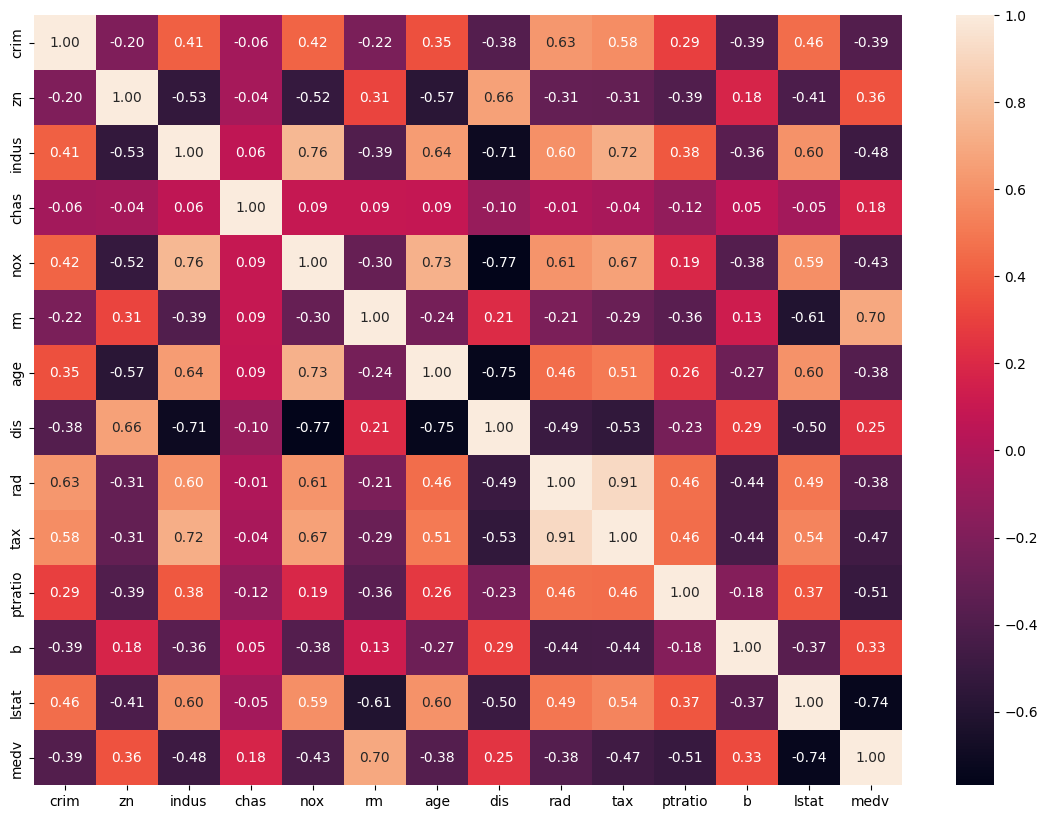

In [359]:
import seaborn as sns

plt.figure(figsize=(14,10))
sns.heatmap(data=data.corr(), annot=True, fmt=".2f")
plt.show()



In [360]:
data.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [361]:
corr_matrix = data.corr()

cols_to_drop = []
# corr_matrix.index[corr_matrix['medv'] > 0.7 ].tolist()
# cols_to_drop = corr_matrix.index[corr_matrix['medv'] < 0.0 ].tolist()

if 'medv' in cols_to_drop:
    cols_to_drop.remove('medv')

data_filtered = data.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")


Dropped columns: []


In [362]:
Y = data_filtered['medv']
X = data_filtered.drop('medv',axis=1)

print(f"Filtered data: {data_filtered.shape}\nOriginal data: {data.shape}")

Filtered data: (506, 14)
Original data: (506, 14)


In [363]:
x_train,x_test,y_train,y_test = train_test_split(X,Y)

In [364]:
model = lr.fit(x_train,y_train)
y_pred = model.predict(x_test)

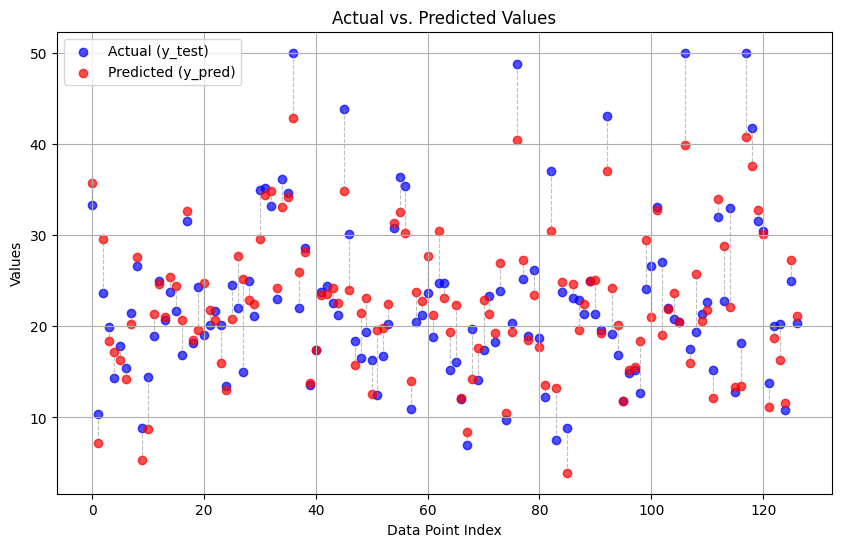

In [365]:
import matplotlib.pyplot as plt
import numpy as np

y_test_arr = np.array(y_test)
y_pred_arr = np.array(y_pred)

plt.figure(figsize=(10, 6))
x_axis = np.arange(len(y_test_arr))

plt.scatter(x_axis, y_test_arr, color='blue', label='Actual (y_test)', alpha=0.7)
plt.scatter(x_axis, y_pred_arr, color='red', label='Predicted (y_pred)', alpha=0.7)

for i in range(len(y_test_arr)):
    plt.plot([x_axis[i], x_axis[i]], [y_test_arr[i], y_pred_arr[i]], 
             color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.title('Actual vs. Predicted Values')
plt.xlabel('Data Point Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.show()


In [366]:

from sklearn.metrics import mean_squared_error, r2_score

print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2: ", r2_score(y_test, y_pred))



RMSE:  3.890384604803871
R2:  0.8051918382496507


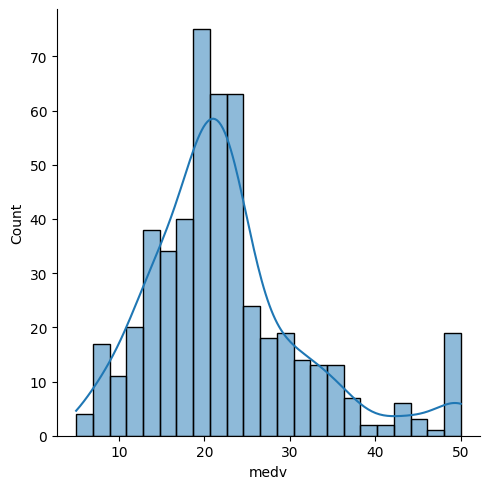

In [367]:
sns.displot(data=data_filtered.medv, kde=True)